In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('save_the_bees.csv')
df.head()

,state,state_code,num_colonies,max_colonies,lost_colonies,percent_lost,added_colonies,renovated_colonies,percent_renovated,quarter,year,varroa_mites,other_pests_and_parasites,diseases,pesticides,other,unknown
0,Alabama,AL,7000,7000,1800,26,2800,250,4,1,2015,10.0,5.4,0.0,2.2,9.1,9.4
1,Arizona,AZ,35000,35000,4600,13,3400,2100,6,1,2015,26.9,20.5,0.1,0.0,1.8,3.1
2,Arkansas,AR,13000,14000,1500,11,1200,90,1,1,2015,17.6,11.4,1.5,3.4,1.0,1.0
3,California,CA,1440000,1690000,255000,15,250000,124000,7,1,2015,24.7,7.2,3.0,7.5,6.5,2.8
4,Colorado,CO,3500,12500,1500,12,200,140,1,1,2015,14.6,0.9,1.8,0.6,2.6,5.9


In [4]:
# Cek tail
df.tail()

,state,state_code,num_colonies,max_colonies,lost_colonies,percent_lost,added_colonies,renovated_colonies,percent_renovated,quarter,year,varroa_mites,other_pests_and_parasites,diseases,pesticides,other,unknown
1448,West Virginia,WV,7500,8000,1100,14,0,220,3,4,2022,33.4,3.8,0.8,0.0,6.4,0.5
1449,Wisconsin,WI,26000,47000,3500,7,140,380,1,4,2022,23.2,21.4,19.4,17.5,9.9,11.7
1450,Wyoming,WY,19500,21000,3200,15,640,0,0,4,2022,22.9,5.9,4.2,0.0,0.0,7.4
1451,Other,OT,30030,30030,480,2,1190,130,0,4,2022,22.4,18.5,0.0,0.0,0.0,0.7
1452,United States,US,2888130,3595030,353910,12,170280,147950,5,4,2022,44.3,19.8,10.3,12.4,14.2,4.7


In [5]:
# Cek columns
df.columns

Index(['state', 'state_code', 'num_colonies', 'max_colonies', 'lost_colonies',
       'percent_lost', 'added_colonies', 'renovated_colonies',
       'percent_renovated', 'quarter', 'year', 'varroa_mites',
       'other_pests_and_parasites', 'diseases', 'pesticides', 'other',
       'unknown'],
      dtype='str')

In [6]:
# Cek 1 kolom
df['max_colonies'].head()

0       7000
1      35000
2      14000
3    1690000
4      12500
Name: max_colonies, dtype: int64

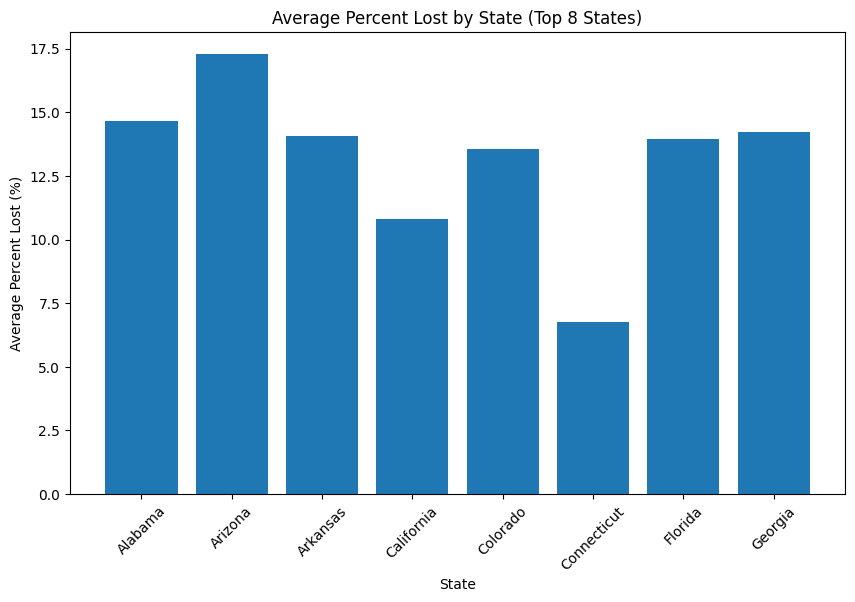

In [7]:
# Gunakan bar chart untuk melihat Average percent lost of 5-8 states (bar chart)
states = df['state'].value_counts().head(8).index
avg_percent_lost = df[df['state'].isin(states)].groupby('state')['percent_lost'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_percent_lost.index, avg_percent_lost.values)
plt.xlabel('State')
plt.ylabel('Average Percent Lost (%)')
plt.title('Average Percent Lost by State (Top 8 States)')
plt.xticks(rotation=45)
plt.show()

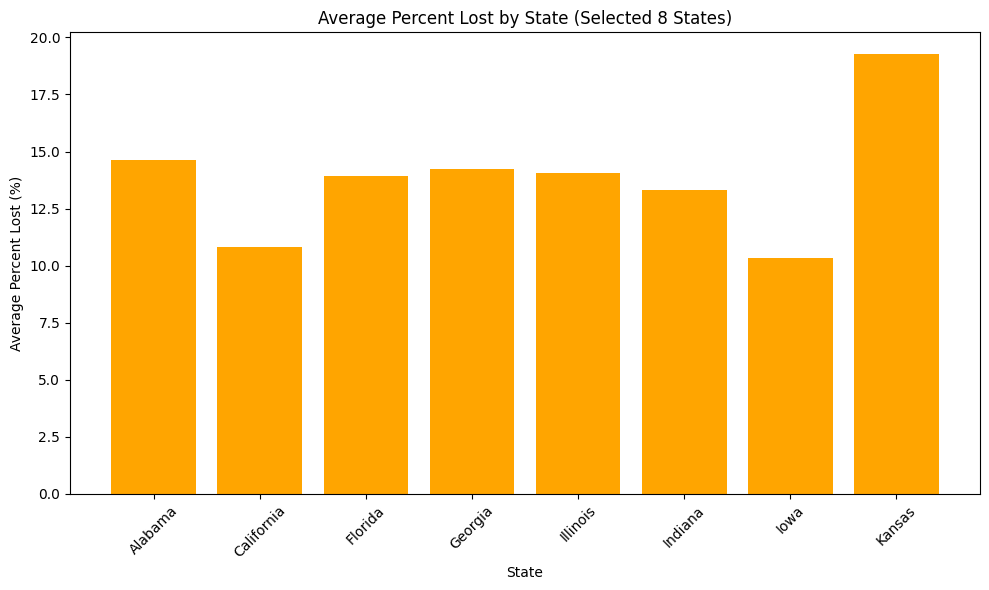

In [8]:
# Cara lain untuk membuat bar chart untuk total jumlah koloni dari 5 - 8 states
selected_states = ['Alabama', 'California', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas']
df_filtered = df[df['state'].isin(selected_states)]
avg_lost_8_states = df_filtered.groupby('state')['percent_lost'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(avg_lost_8_states['state'], avg_lost_8_states['percent_lost'], color='orange')
plt.title('Average Percent Lost by State (Selected 8 States)')
plt.xlabel('State')
plt.ylabel('Average Percent Lost (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

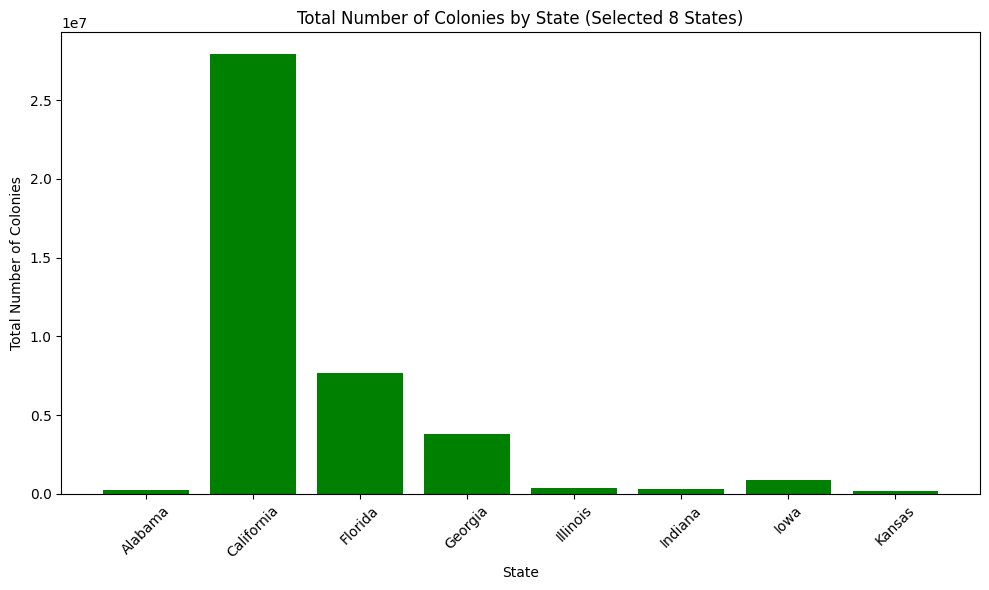

In [9]:
# Membuat bar chart untuk total jumlah koloni dari 5 - 8 states
total_colonies = df[df['state'].isin(selected_states)].groupby('state')['num_colonies'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(total_colonies['state'], total_colonies['num_colonies'], color='green')
plt.title('Total Number of Colonies by State (Selected 8 States)')
plt.xlabel('State')
plt.ylabel('Total Number of Colonies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

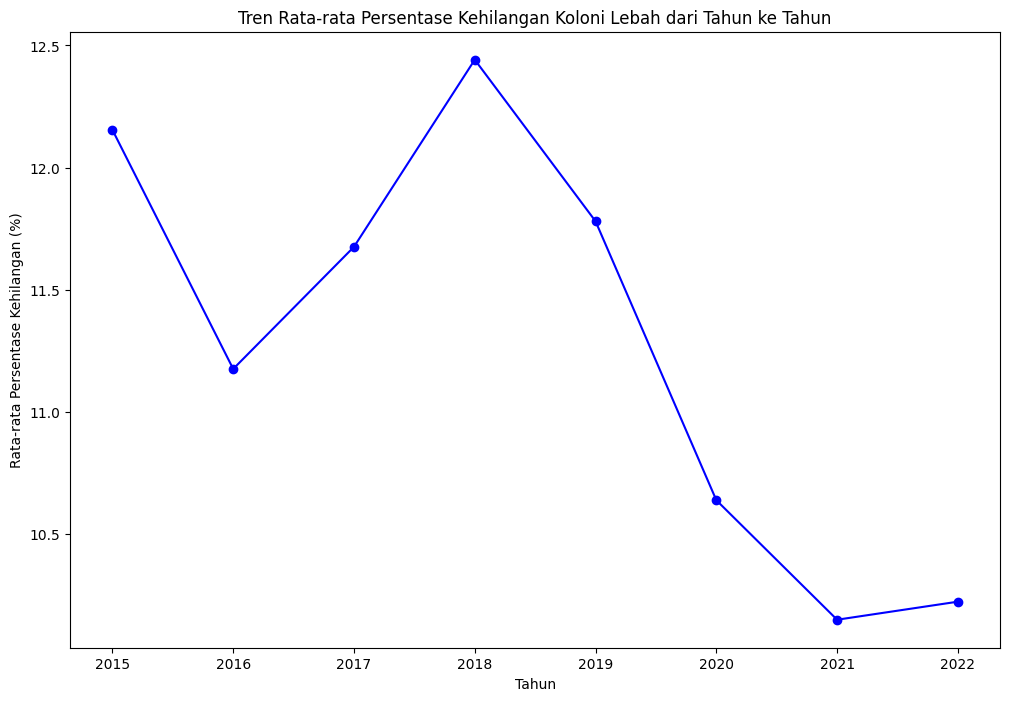

In [10]:
# Buat line plot untuk menunjukan apakah rata-rata persentase kehilangan (percent_lost) cenderung naik atau turun dari tahun ke tahun?
bees_per_year = df.groupby('year')['percent_lost'].mean().reset_index()
plt.figure(figsize=(12, 8))
plt.plot(bees_per_year['year'], bees_per_year['percent_lost'], marker='o', color='blue')
plt.title('Tren Rata-rata Persentase Kehilangan Koloni Lebah dari Tahun ke Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Persentase Kehilangan (%)')
plt.show()

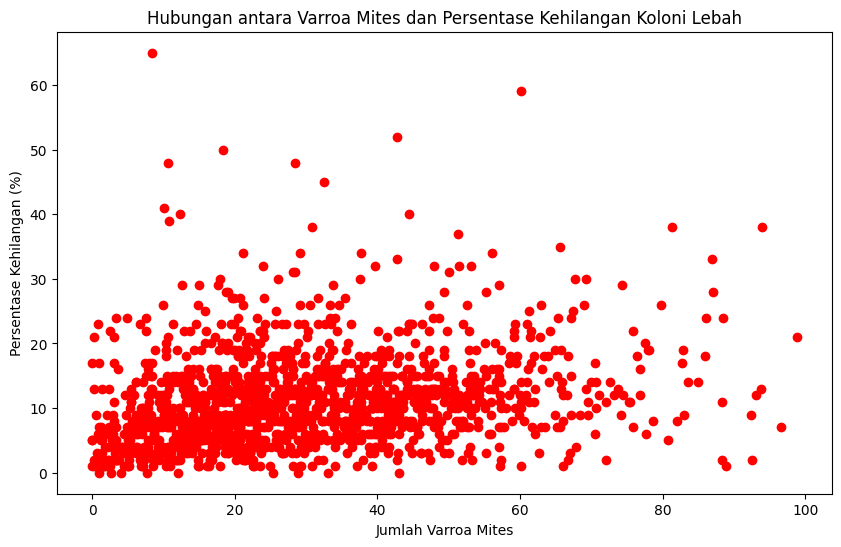

In [11]:
# Buat scatter plot untuk melihat hubungan antara presentase kehilangan (percent_lost) dan jumlah Varroa Mites (varroa_mites)
plt.figure(figsize=(10, 6))
plt.scatter(df['varroa_mites'], df['percent_lost'], color='red')
plt.title('Hubungan antara Varroa Mites dan Persentase Kehilangan Koloni Lebah')
plt.xlabel('Jumlah Varroa Mites')
plt.ylabel('Persentase Kehilangan (%)')
plt.show()